# 蛋白质-表型关联组文章复现

- 文章标题：Plasma proteomic signatures of social isolation and loneliness associated with morbidity and mortality


In [1]:
from dotenv import load_dotenv
load_dotenv("/mnt/disk1/project/project/aikb/.env")


True

In [2]:
import polars as pl
from datalake import scan_table, get_catalog

catalog = get_catalog()

In [3]:

rename_map = {
    "participant.p131286": "htn_date",
    "participant.p31": "sex",
    "participant.p21003_i0": "age",
    "participant.p21001_i0": "bmi",
    "participant.p1239_i0": "smoking_current",
    "participant.p1249_i0": "smoking_past",
    "participant.p20117_i0": "smoking_pack_years",
    "participant.p6138_i0": "education",
    "participant.p738_i0": "income",
    "participant.p22189": "townsend_di",
    "participant.p54_i0": "assessment_centre",
    "participant.p4080_i0_a0": "systolic_bp_1",
    "participant.p4079_i0_a0": "diastolic_bp_1",
    "participant.p4080_i0_a1": "systolic_bp_2",
    "participant.p4079_i0_a1": "diastolic_bp_2",
    "participant.p2966_i0": "age_htn_diagnosed",
}


hp_df = (
    scan_table("ukb.hypertension_cohort")
    .rename(rename_map)  # Rename field: ukb code to readable name
    .with_columns(  # Processing education field
        pl.col("education")
        .str.strip_chars("[]")
        .str.split(",")
        .list.eval(pl.element().cast(pl.Int32))
        .list.min()
        .replace(-7, 0)  # -7 (无学历) 映射为 0
    ).with_columns(
        pl.col('htn_date').is_not_null().alias('hpt')
    )
)

olink_df = scan_table("ukb.hypertension_cohort").with_columns(
    pl.col("eid").cast(pl.String)
)  # convert eid datatype



In [4]:
# catalog.drop_table("ukb.hpt_cov_clean")
join_tb = catalog.create_table_if_not_exists(
    "ukb.hpt_cov_clean", schema=hp_df.schema.to_arrow()
)
hp_df.collect().write_iceberg(join_tb, "overwrite")

/tmp/ipykernel_1495731/1289319491.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  "ukb.hpt_cov_clean", schema=hp_df.schema.to_arrow()
Unable to resolve region for bucket warehouse


## 蛋白质组Logistic回归

- 为了获取p值，Logistic回归使用statsmodels包实现
- jupyter notebook的垃圾回收机制有所不同，因此处理大规模数据分析任务容易发生OOM，批量处理方法已重构到独立脚本
- 数据处理脚本： logistics.py



## 拟合模型
**多元逻辑回归模型（Multiple Logistic Regression Model）**

$$
\log\left(\frac{P(\text{hypertension}=1)}{1 - P(\text{hypertension}=1)}\right) = \beta_0 + \beta_1 \cdot \text{protein(x)} + \beta_2 \cdot \text{sex} + \beta_3 \cdot \text{age} + \beta_4 \cdot \text{bmi} + \dots
$$

- **左侧**：logit 变换（自然对数尺度下的对数几率）
- **右侧**：线性组合（蛋白 + 协变量）
- **估计方法**：最大似然估计（MLE）



In [5]:
COVARIANCE_FIELDS = [
    "sex",
    "age",
    "bmi",
    "smoking_current",
    "smoking_past",
    "smoking_pack_years",
    "education",
    "income",
]

OUTCOME_FIELD = "hpt"

OLINK_TABLE = "ukb.olink_instance_0"
COV_TABLE = "ukb.hpt_cov_clean"
RESULT_TABLE = "ukb.pwas_hypertension_logit"


In [6]:
logistic_df = scan_table("ukb.pwas_hypertension_logit").filter(
    ~pl.col("protein").is_in(["olink_instance_0.eid", *list(hp_df.schema.keys())])
)

protein_logistic_result_df = logistic_df.sql(
    "SELECT * FROM self WHERE variable = protein"
)

# sink data to iceberg
protein_logistic_result_tb = catalog.create_table_if_not_exists(
    "ukb.proteome.protein_logistic_result",
    schema=protein_logistic_result_df.schema.to_arrow()
)

# 分批写入iceberg
# for batch_df in protein_logistic_result_df.collect_batches(chunk_size=1_000):
#     protein_logistic_result_tb.append(batch_df.to_arrow())

/tmp/ipykernel_1495731/2669505062.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  ~pl.col("protein").is_in(["olink_instance_0.eid", *list(hp_df.schema.keys())])
/tmp/ipykernel_1495731/2669505062.py:12: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema=protein_logistic_result_df.schema.to_arrow()


In [11]:
import numpy as np

proteo_df = scan_table("ukb.proteome.protein_logistic_result")
or_proteom_logistic_df = proteo_df.with_columns(pl.col('coef').exp().alias('or'))

or_proteom_logistic_df.head().collect()

protein,variable,coef,std_err,z,pvalue,ci_lower,ci_upper,or
str,str,f64,f64,f64,f64,f64,f64,f64
"""endou""","""endou""",0.013081,0.021153,0.618406,0.536308,-0.028379,0.054541,1.013167
"""enah""","""enah""",0.091527,0.019554,4.680783,0.000003,0.053202,0.129851,1.095846
"""elob""","""elob""",0.040678,0.027723,1.467283,0.142299,-0.013659,0.095014,1.041517
"""eloa""","""eloa""",0.103457,0.016811,6.154148,7.5482e-10,0.070508,0.136406,1.108998
"""eln""","""eln""",0.243774,0.030236,8.062266,7.4893e-16,0.184511,0.303036,1.276055


In [12]:
tb = catalog.create_table_if_not_exists(
    identifier="ukb.proteome.protein_logistic_result_with_or", 
    schema=or_proteom_logistic_df.schema.to_arrow()
    )

# save data
or_proteom_logistic_df.collect().write_iceberg(tb, "overwrite")

/tmp/ipykernel_1490628/141601517.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema=or_proteom_logistic_df.schema.to_arrow()


## PWAS结果分析
- 显著性指标: $p < 0.05$
- 进行Bonferroni校正阈值: $\alpha_{new} = \frac{\alpha}{n}$

In [13]:
pwas_df = scan_table("ukb.proteome.protein_logistic_result_with_or")

p_standard = 0.05
prot_num = pwas_df.sql("SELECT COUNT(protein) FROM self").collect().item()
bonferroni = p_standard / prot_num
significant_pwas_df = pwas_df.filter(pl.col("pvalue").lt(bonferroni))

significant_pwas_df.describe()

statistic,protein,variable,coef,std_err,z,pvalue,ci_lower,ci_upper,or
str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""1026""","""1026""",1026.0,1026.0,1026.0,1026.0,1026.0,1026.0,1026.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,0.161799,0.024325,6.82492,8.8261e-7,0.114122,0.209475,1.19817
"""std""",null,null,0.197918,0.010996,6.642528,0.000003,0.192741,0.205239,0.231805
"""min""","""a1bg""","""a1bg""",-0.746645,0.006044,-20.747202,9.3123e-204,-0.85637,-0.63692,0.473954
"""25%""",null,null,0.082647,0.015951,4.963843,3.8428e-27,0.053027,0.112909,1.086158
"""50%""",null,null,0.152897,0.022615,6.930228,1.2882e-13,0.108847,0.196339,1.165205
"""75%""",null,null,0.263153,0.031093,10.277077,5.3127e-8,0.210853,0.317225,1.301026
"""max""","""znrd2""","""znrd2""",0.842464,0.134576,30.45826,0.000017,0.741518,1.031732,2.322081


## 可视化

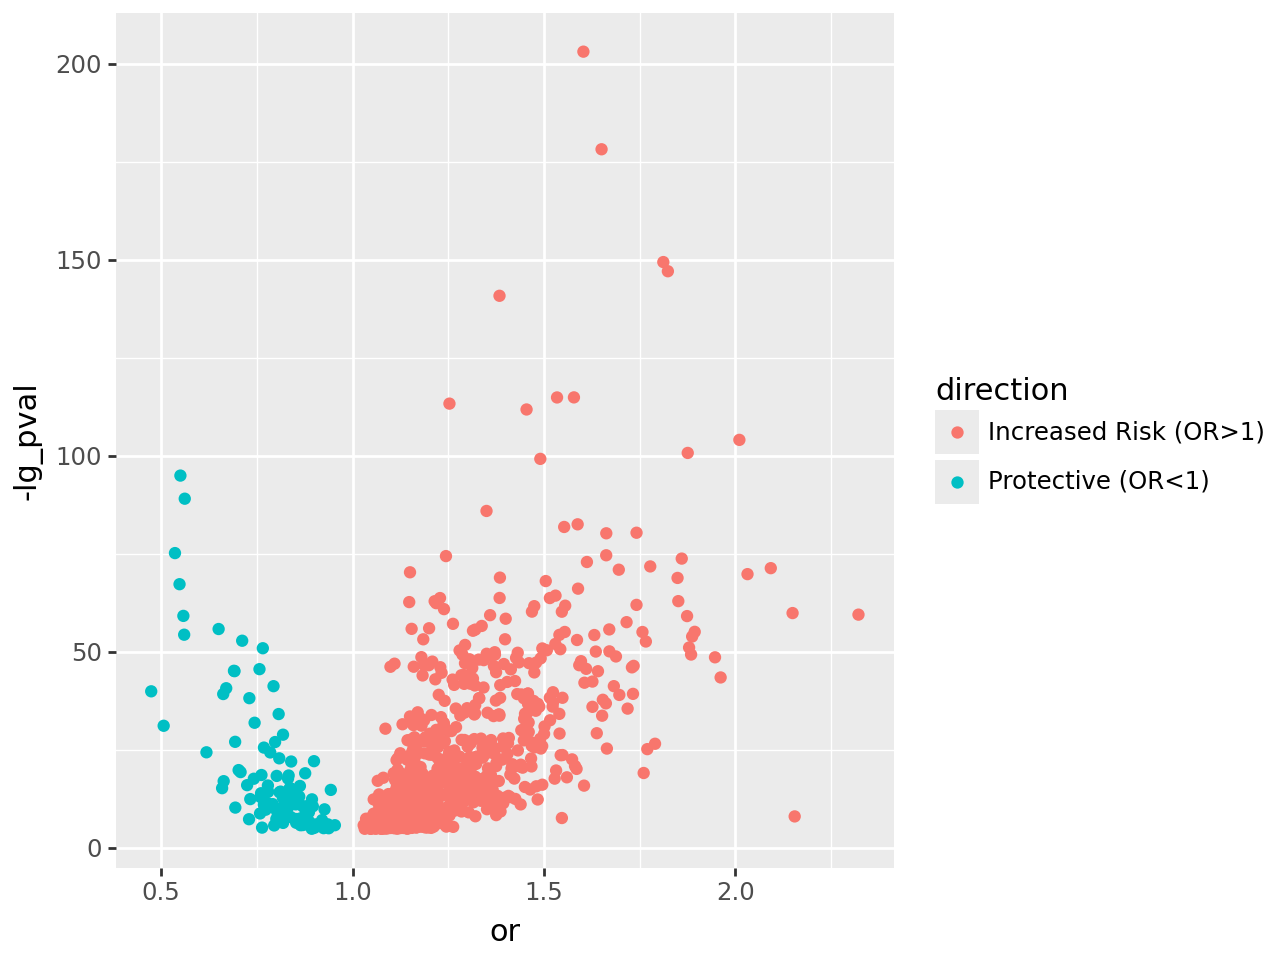

In [14]:
import pandas as pwas_df
import numpy as np
from plotnine import ggplot, aes, geom_point

data = (
    significant_pwas_df.select(["protein", "or", "pvalue"])
    .with_columns(
        pl.col("pvalue").map_batches(lambda x: -np.log10(x)).alias("-lg_pval")
    )
    .collect()
    .to_pandas()
)

data["direction"] = data["or"].apply(
    lambda x: "Increased Risk (OR>1)" if x > 1 else "Protective (OR<1)"
)

ggplot(data=data, mapping=aes(x="or", y="-lg_pval", color="direction")) + geom_point()